# PVTT model — PEP725 winter wheat

Loads the CPF PEP725 winter wheat dataset, explores it visually, fits a
Photo-Vernalization Thermal Time (PVTT) model on a temporal train/test split
(train: 1986–2009, test: 2010–2015), and evaluates the result.

In [1]:
import matplotlib.pyplot as plt

from pysephone.constants import KEY_OBSERVATIONS
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.pvtt import PVTTModel
from pysephone.visualize.dataset import (
    observation_doy_histograms,
    observation_doy_over_time,
    observation_map,
    observation_mean_trend,
)

## 1. Load data

In [2]:
cal = Calendar()  # default: 10-01 start, 365 days — correct for winter wheat
features = OpenMeteoFeatures(calendar=cal)

dataset = Dataset.load(
    'CPF_PEP725_winter_wheat',
    calendar=cal,
    feature_providers=[features],
)
dataset.download_features(verbose=True)

print(f"Dataset: {len(dataset)} samples")
print(f"Years:   {min(dataset.years)}–{max(dataset.years)}")
print(f"Locations: {len(dataset.locations)}")
print(f"Observation types: {dataset.observation_types}")

Checking for missing meteo data: 100%|██████████| 13366/13366 [00:10<00:00, 1294.51it/s, step=daily, data_key=daylight_duration, location_id=(pep725, 911), year=1995, n_missing=0/13366]    


Dataset: 5284 samples
Years:   1987–2015
Locations: 683
Observation types: ['BBCH_0', 'BBCH_51']


## 2. Explore the observations

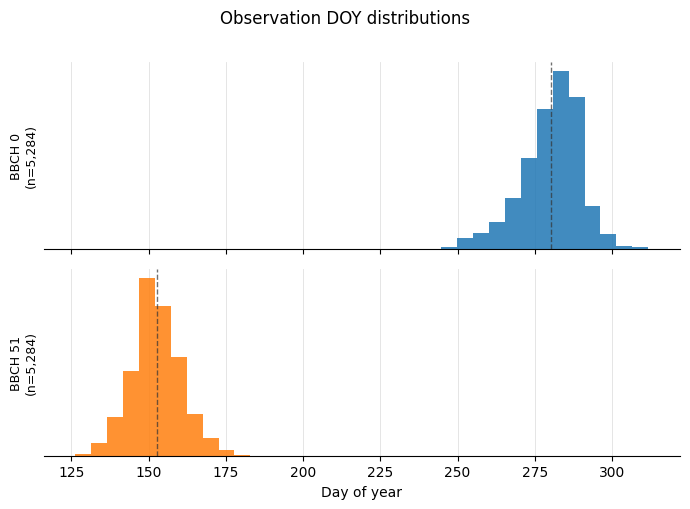

In [3]:
obs = dataset.observations

fig = observation_doy_histograms(obs)
plt.tight_layout()
plt.show()

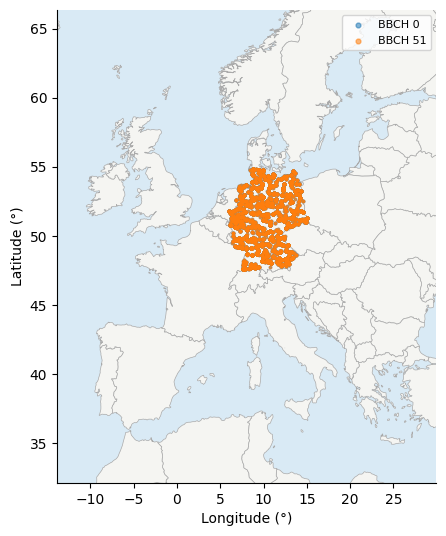

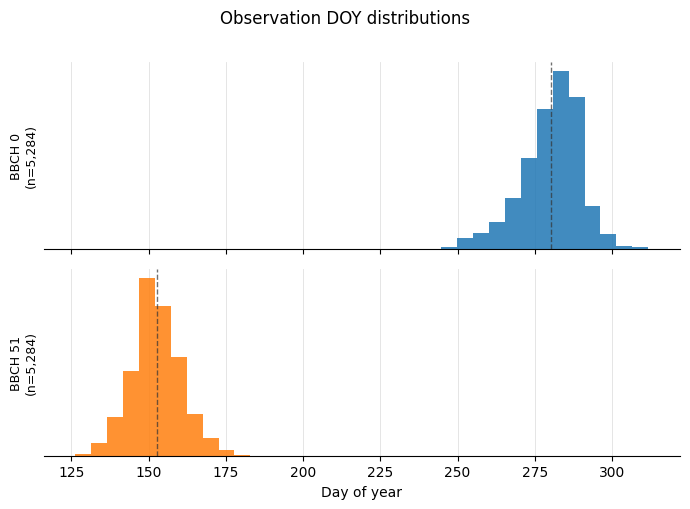

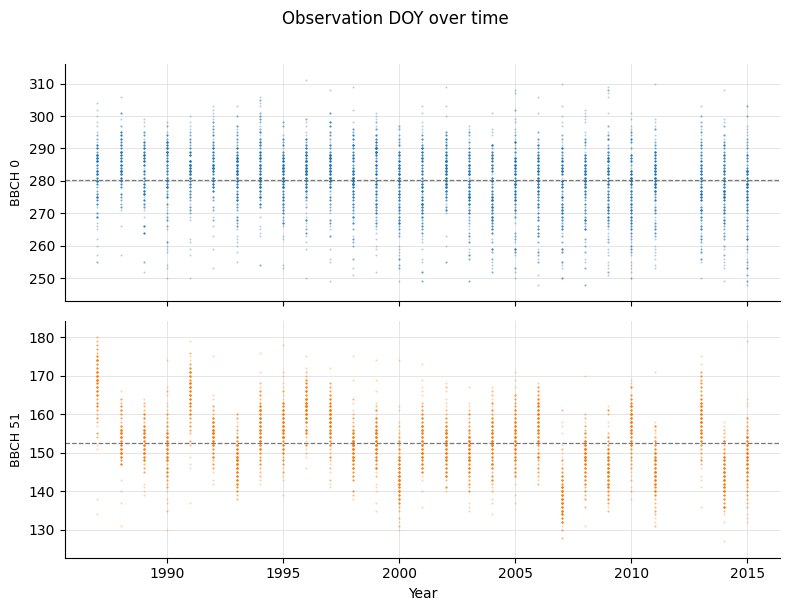

In [4]:
obs = dataset.observations

fig = observation_map(obs)
plt.tight_layout()
plt.show()

fig = observation_doy_histograms(obs)
plt.tight_layout()
plt.show()

fig = observation_doy_over_time(obs)
plt.tight_layout()
plt.show()

## 3. Train / test split

Temporal cutoff: **train 1986–2009**, **test 2010–2015**.

In [5]:
CUTOFF = 2010

years_sorted = sorted(dataset.years)
years_trn = [y for y in years_sorted if y < CUTOFF]
years_tst = [y for y in years_sorted if y >= CUTOFF]

ds_trn = dataset.select_years(years_trn)
ds_tst = dataset.select_years(years_tst)

print(f"Train: {len(ds_trn)} samples ({min(years_trn)}–{max(years_trn)})")
print(f"Test:  {len(ds_tst)} samples ({min(years_tst)}–{max(years_tst)})")

Train: 4309 samples (1987–2009)
Test:  975 samples (2010–2015)


## 4. Fit PVTT model

In [6]:
def target_fn(s):
    return s[KEY_OBSERVATIONS]['BBCH_51']

model, _ = PVTTModel.fit(
    target_fn=target_fn,
    dataset=ds_trn,
    model_kwargs=dict(
        threshold_pvtt=800.0,
        threshold_vern=30.0,
        t_base=1.0,
        t_limit=32.0,
        t_upper=40.0,
        p_base=7.0,
        p_saturation=17.0,
        key_sow='BBCH_0',
        opt_max_time=60.0,  # max 60 s per optimisation phase
    ),
)

print('Fitted parameters:')
for k, v in model.params.items():
    print(f'  {k:20s} = {v:.4f}')

Fitted parameters:
  th_pvtt              = 499.6055
  th_vern              = 34.8159
  t_base               = 0.2776
  t_limit              = 32.0000
  t_upper              = 40.0000
  p_base               = 8.3379
  p_saturation         = 18.9941


## 5. Evaluate

In [7]:
result = SingleTargetRegression.run(
    model=model,
    dataset_train=ds_trn,
    dataset_test=ds_tst,
    target_fn=target_fn,
    run_name='pvtt_pep725_winter_wheat',
)

metrics = result.compute_metrics()

print('Train')
for k, v in metrics['train'].items():
    print(f'  {k:15s} {v:.3f}')

print('\nTest')
for k, v in metrics['test'].items():
    print(f'  {k:15s} {v:.3f}')

Train
  n               4309.000
  mae             4.022
  mse             27.294
  rmse            5.224
  r2              0.572
  pearson_r       0.758
  kendall_tau     0.572
  bias            -0.342

Test
  n               975.000
  mae             4.086
  mse             30.043
  rmse            5.481
  r2              0.552
  pearson_r       0.777
  kendall_tau     0.622
  bias            1.838


## 6. Evaluation plots

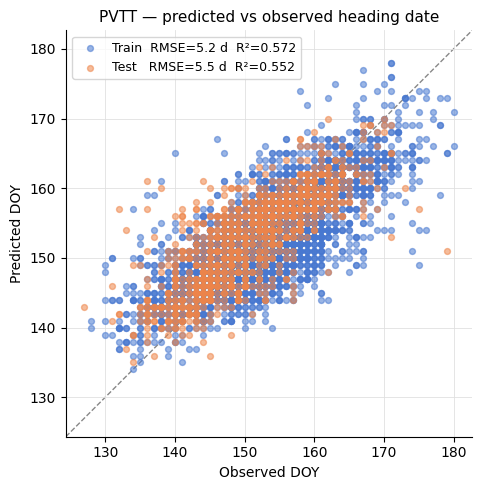

In [ ]:
fig = result.plot_scatter(title='PVTT — predicted vs observed heading date')
plt.tight_layout()
plt.show()

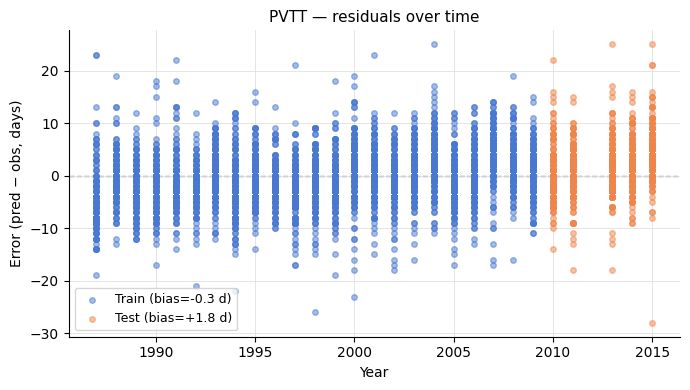

In [ ]:
fig = result.plot_residuals_over_time(title='PVTT — residuals over time')
plt.tight_layout()
plt.show()

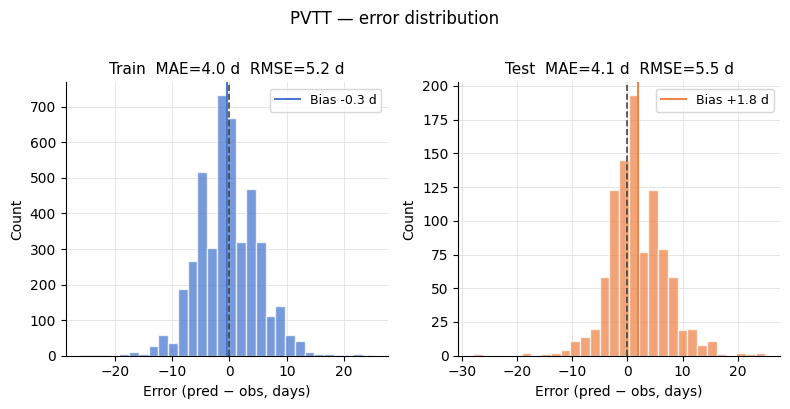

In [ ]:
fig = result.plot_error_distribution(title='PVTT — error distribution')
plt.tight_layout()
plt.show()

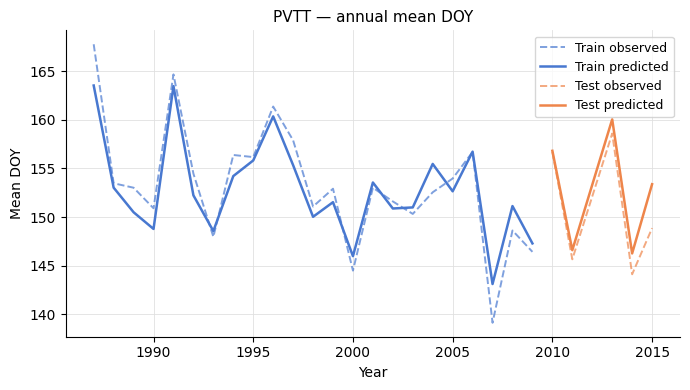

In [ ]:
fig = result.plot_annual_mean_doy(title='PVTT — annual mean DOY')
plt.tight_layout()
plt.show()

## 7. Save

In [ ]:
# result.save()
# model.save('pvtt_pep725_winter_wheat')
# print('Saved.')

Saved.
